# New Section

# 1.Setup & Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"

# cek semua file yang ada di folder
print("Isi folder:")
print(os.listdir(folder_path))

# load dataset hasil filtering
df = pd.read_csv(f"{folder_path}/dataset_hantavirus_mei_juni_2026.csv")
print(f"\nJumlah data: {len(df)}")
df.head()

Mounted at /content/drive
Isi folder:
['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_final_for_split.csv', 'hasil_prediksi.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'hasil_evaluasi.pkl', 'dataset_hantavirus_mei_juni_2026.csv', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'hasil_pembobotan_tfidf_bab4.gsheet', 'frekuensi_fitur_tfidf_bab4.csv', 'hasil_pembobotan_tfidf_bab4.csv', 'inset_positif.gsheet', 'inset_negatif.gsheet', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'confusion_matrix_linearsvc.csv', 'confusion_matrix_linearsvc.png', 'confusion_matrix_naivebayes.csv', 'confusion_matrix_naivebayes.png', 'perbandingan_performa_model.csv', 'perbandingan_kinerja_model.png', 'distribusi_label_sentimen.csv', 'hasil_analisis_sentimen.png', 'dataset_hantavirus_labeled.gsheet', 'dataset_hantavirus_preprocessed.csv', 'dataset_cleaning.csv', 'dataset_hantavirus_casefolding.csv', 'dataset_hantavirus_normalization.

,tanggal,nama_akun,teks
0,2026-05-05 04:18:23+00:00,aajuianbakk9,bisnis apa lagi ini
1,2026-05-05 03:11:33+00:00,firmandafahmis,libur berapa tahun lagi ini?
2,2026-05-05 04:34:11+00:00,fashionstudio_ai,project siapa lagi ini ??
3,2026-05-05 02:48:28+00:00,milavryn,Gua gak mau kek Covid lagi tolong 😭
4,2026-05-05 03:39:34+00:00,dempo20,klian percaya???


In [3]:
output_path = f"{folder_path}/dataset_hantavirus_preprocessed.csv"
df.to_csv(output_path, index=False)
print(f"Dataset hasil preprocessing disimpan di: {output_path}")

Dataset hasil preprocessing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_preprocessed.csv


In [4]:
import os
folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"
print(os.listdir(folder_path))

['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_final_for_split.csv', 'hasil_prediksi.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'hasil_evaluasi.pkl', 'dataset_hantavirus_mei_juni_2026.csv', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'hasil_pembobotan_tfidf_bab4.gsheet', 'frekuensi_fitur_tfidf_bab4.csv', 'hasil_pembobotan_tfidf_bab4.csv', 'inset_positif.gsheet', 'inset_negatif.gsheet', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'confusion_matrix_linearsvc.csv', 'confusion_matrix_linearsvc.png', 'confusion_matrix_naivebayes.csv', 'confusion_matrix_naivebayes.png', 'perbandingan_performa_model.csv', 'perbandingan_kinerja_model.png', 'distribusi_label_sentimen.csv', 'hasil_analisis_sentimen.png', 'dataset_hantavirus_labeled.gsheet', 'dataset_hantavirus_preprocessed.csv', 'dataset_cleaning.csv', 'dataset_hantavirus_casefolding.csv', 'dataset_hantavirus_normalization.csv', 'dataset_hantavirus_tokenizing.c

In [5]:
print("Hasil Keseluruhan Data" in os.listdir("/content/drive/MyDrive"))

True


# Filtering Bahasa Daerah

In [6]:
# ============================================================
# DETEKSI KANDIDAT KOMENTAR BAHASA DAERAH
# Dataset awal: 5.199 komentar
# ============================================================

import re
import pandas as pd


# ------------------------------------------------------------
# 1. Daftar kata indikator bahasa daerah
# ------------------------------------------------------------

kata_daerah = {

    "Jawa": [
        "opo",
        "iki",
        "ora",
        "wes",
        "wis",
        "nek",
        "ngunu",
        "ngono",
        "maneh",
        "mbok",
        "kowe",
        "percoyo",
        "ngurus",
        "karepmu",
        "wayane",
        "bongso",
        "madyang"
    ],

    "Sunda": [
        "aing",
        "euy",
        "teu",
        "henteu",
        "naon",
        "ieu",
        "ulah",
        "pagawean",
        "kumaha",
        "atuh"
    ],

    "Minang": [
        "apo",
        "ndak",
        "indak",
        "dima",
        "mano",
        "iko",
        "bana",
        "den",
        "nyo"
    ]
}


# ------------------------------------------------------------
# 2. Fungsi deteksi bahasa daerah
# ------------------------------------------------------------

def deteksi_bahasa_daerah(teks):

    teks = str(teks).lower()

    hasil = []

    for bahasa, daftar_kata in kata_daerah.items():

        kata_terdeteksi = []

        for kata in daftar_kata:

            # Mencocokkan kata secara utuh
            pola = r'\b' + re.escape(kata) + r'\b'

            if re.search(pola, teks):
                kata_terdeteksi.append(kata)

        if kata_terdeteksi:

            hasil.append(
                f"{bahasa}: {', '.join(sorted(set(kata_terdeteksi)))}"
            )

    return " | ".join(hasil)


# ------------------------------------------------------------
# 3. Deteksi pada seluruh dataset
# ------------------------------------------------------------

df["indikator_bahasa_daerah"] = df["teks"].apply(
    deteksi_bahasa_daerah
)


# ------------------------------------------------------------
# 4. Ambil data yang terdeteksi sebagai kandidat
# ------------------------------------------------------------

df_kandidat_daerah = df[
    df["indikator_bahasa_daerah"] != ""
].copy()


# ------------------------------------------------------------
# 5. Tampilkan jumlah hasil deteksi
# ------------------------------------------------------------

print("==============================================")
print("HASIL DETEKSI KANDIDAT BAHASA DAERAH")
print("==============================================")

print(f"Jumlah data awal       : {len(df)}")
print(f"Jumlah kandidat daerah : {len(df_kandidat_daerah)}")


# ------------------------------------------------------------
# 6. Tampilkan seluruh kandidat
# ------------------------------------------------------------

pd.set_option("display.max_colwidth", None)

display(
    df_kandidat_daerah[
        ["teks", "indikator_bahasa_daerah"]
    ].reset_index(drop=True)
)

HASIL DETEKSI KANDIDAT BAHASA DAERAH
Jumlah data awal       : 5199
Jumlah kandidat daerah : 82


,teks,indikator_bahasa_daerah
0,Halahh opo maneh iki,"Jawa: iki, maneh, opo"
1,ORA NGURUSSSSSSS🙏,Jawa: ora
2,ora pecoyo,Jawa: ora
3,"wes karepmu ae....,nek libur berarti wayane istirahat di rmh,menikmati hidup","Jawa: karepmu, nek, wayane, wes"
4,bisnis vucksin lagiii.....saya suruh vucsin lagiin....ndak mau q...tolonggg!!!!!,Minang: ndak
...,...,...
77,ki bongso op menehhh .. wes penting madyang,"Jawa: bongso, madyang, wes"
78,WIS mulai muncul dramanya,Jawa: wis
79,"Media ulah nga gembor "" masalah virus. yg kena mah di Rawat z g usah di liput",Sunda: ulah
80,aku wis ra peduli😏,Jawa: wis


In [7]:
# ============================================================
# MENAMPILKAN 82 KANDIDAT BAHASA DAERAH
# ============================================================

# Buat salinan kandidat
df_daerah_tampil = df_kandidat_daerah[
    ["teks", "indikator_bahasa_daerah"]
].copy()

# Nomor urut 1–82
df_daerah_tampil.insert(
    0,
    "No",
    range(1, len(df_daerah_tampil) + 1)
)

# Atur tampilan agar teks komentar terlihat lengkap
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

# Tampilkan seluruh kandidat
display(df_daerah_tampil)

,No,teks,indikator_bahasa_daerah
16,1,Halahh opo maneh iki,"Jawa: iki, maneh, opo"
382,2,ORA NGURUSSSSSSS🙏,Jawa: ora
553,3,ora pecoyo,Jawa: ora
558,4,"wes karepmu ae....,nek libur berarti wayane istirahat di rmh,menikmati hidup","Jawa: karepmu, nek, wayane, wes"
595,5,bisnis vucksin lagiii.....saya suruh vucsin lagiin....ndak mau q...tolonggg!!!!!,Minang: ndak
643,6,behhh opo nehh iki😭😭😭,"Jawa: iki, opo"
756,7,Ayo wes kapan prei ne,Jawa: wes
843,8,"opo neh ikiii,,corona part 2 yeee iki","Jawa: iki, opo"
853,9,opo maneh 😳,"Jawa: maneh, opo"
894,10,wes mulaiiii....,Jawa: wes


In [8]:
# ============================================================
# FILTER KOMENTAR BAHASA DAERAH
# Berdasarkan hasil pemeriksaan manual 82 kandidat
# ============================================================

# Nomor kandidat yang DIPERTAHANKAN
nomor_dipertahankan = [
    5, 17, 20, 55, 56, 59, 62, 63, 80
]

# Ambil index asli dari kandidat yang dipertahankan
index_dipertahankan = df_kandidat_daerah.iloc[
    [no - 1 for no in nomor_dipertahankan]
].index

# Semua index kandidat bahasa daerah
index_semua_kandidat = df_kandidat_daerah.index

# Tentukan index yang benar-benar akan dihapus
index_bahasa_daerah = index_semua_kandidat[
    ~index_semua_kandidat.isin(index_dipertahankan)
]

# Buat dataset baru tanpa komentar bahasa daerah
df_filtered = df.drop(
    index=index_bahasa_daerah
).copy()

# Reset index
df_filtered.reset_index(drop=True, inplace=True)


# ============================================================
# HASIL FILTERING
# ============================================================

print("==============================================")
print("HASIL FILTERING BAHASA DAERAH")
print("==============================================")

print(f"Jumlah data awal       : {len(df)}")
print(f"Jumlah kandidat        : {len(df_kandidat_daerah)}")
print(f"Data bahasa daerah     : {len(index_bahasa_daerah)}")
print(f"Data dipertahankan     : {len(index_dipertahankan)}")
print(f"Jumlah data setelah    : {len(df_filtered)}")

HASIL FILTERING BAHASA DAERAH
Jumlah data awal       : 5199
Jumlah kandidat        : 82
Data bahasa daerah     : 73
Data dipertahankan     : 9
Jumlah data setelah    : 5126


# 2.Text Preprocessing

In [9]:
!pip install Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.7 MB/s eta 0:00:00


## 2.1 Cleaning

In [10]:
# ============================================================
# DATASET HASIL FILTERING BAHASA DAERAH
# ============================================================

# Menggunakan dataset hasil filtering bahasa daerah
df = df_filtered.copy()

print(f"Jumlah data setelah filtering bahasa daerah: {len(df)}")

Jumlah data setelah filtering bahasa daerah: 5126


In [11]:
# digunakan untuk mencari url, mention, hastag, angka,dan karakter yg ga diinginkan
import re
import string

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "\U0001FA70-\U0001FAFF"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r"", text)

def cleaning(text):
    if not isinstance(text, str):
        return ""

#untuk menghapus emoji
    text = remove_emoji(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
df["text_clean"] = df["teks"].apply(cleaning)

# Menghapus data yang kosong setelah cleaning
df = df[
    df["text_clean"].notna() &
    (df["text_clean"].str.strip() != "")
].copy()

print(f"Jumlah data setelah cleaning: {len(df)}")

Jumlah data setelah cleaning: 4818


In [13]:
df.to_csv(
    f"{folder_path}/dataset_cleaning.csv",
    index=False
)

print("Hasil cleaning berhasil disimpan di Google Drive.")

Hasil cleaning berhasil disimpan di Google Drive.


## 2.2 Case Folding

In [14]:
def case_folding(text):
    return text.lower()

df["text_casefolding"] = df["text_clean"].apply(case_folding)

df[["text_clean", "text_casefolding"]].head(10)

,text_clean,text_casefolding
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,Gua gak mau kek Covid lagi tolong,gua gak mau kek covid lagi tolong
4,klian percaya,klian percaya
5,Singkat saja Kapan mulai libur Berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya WHO,jangan percaya yg namanya who
7,To the point aja berapa tahun,to the point aja berapa tahun
8,udahla anj cape bgt cape,udahla anj cape bgt cape
9,saham apa yg bakal naik nih,saham apa yg bakal naik nih


In [15]:
output_path = f"{folder_path}/dataset_hantavirus_casefolding.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil case folding disimpan di: {output_path}")

Dataset hasil case folding disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_casefolding.csv


## 2.3 Normalization

In [16]:
#Membaca file dari hasil casefolding
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_casefolding.csv"
)
#Untuk menangani nilai kosong pada teks casefolding
df["text_casefolding"] = df["text_casefolding"].fillna("")

In [17]:
#Membaca kamus normalisasi
kamus_df = pd.read_csv(
    f"{folder_path}/kamus_normalisasi.csv"
)
#Merubah kata dari dataframe jadi python dictionary
kamus_normalisasi = dict(
    zip(kamus_df["slang"], kamus_df["formal"])
)
#Menghitung jumlah pasangan kata di kamus
print(f"Jumlah pasangan kata di kamus: {len(kamus_normalisasi)}")

Jumlah pasangan kata di kamus: 4331


In [18]:
#Menerapkan fungsi normalisasi
def normalisasi(text):
    words = text.split()
    words = [kamus_normalisasi.get(word, word) for word in words]
    return " ".join(words)

In [19]:
#fungsi yg digunakan untuk melakukan pergantian kata
df["text_normalization"] = df["text_casefolding"].apply(normalisasi)

df[["text_casefolding", "text_normalization"]].head(10)

,text_casefolding,text_normalization
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,gua gak mau kek covid lagi tolong,gua enggak mau kayak covid lagi tolong
4,klian percaya,kalian percaya
5,singkat saja kapan mulai libur berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya who,jangan percaya yang namanya who
7,to the point aja berapa tahun,tapi the point saja berapa tahun
8,udahla anj cape bgt cape,udahla anjing capek banget capek
9,saham apa yg bakal naik nih,saham apa yang bakal naik nih


In [20]:
output_path = f"{folder_path}/dataset_hantavirus_normalization.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil normalisasi disimpan di: {output_path}")

Dataset hasil normalisasi disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_normalization.csv


## 2.4 Tokenizing

In [21]:
#membaca dataset hasil normalisasi
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_normalization.csv"
)
#untuk menangani nilai kosong
df["text_normalization"] = df["text_normalization"].fillna("")

In [22]:
#proses yg diterapkan kesetiap baris dan kolom
df["text_token"] = df["text_normalization"].apply(lambda x: x.split())

df[["text_normalization", "text_token"]].head(10)

,text_normalization,text_token
0,bisnis apa lagi ini,"[bisnis, apa, lagi, ini]"
1,libur berapa tahun lagi ini,"[libur, berapa, tahun, lagi, ini]"
2,project siapa lagi ini,"[project, siapa, lagi, ini]"
3,gua enggak mau kayak covid lagi tolong,"[gua, enggak, mau, kayak, covid, lagi, tolong]"
4,kalian percaya,"[kalian, percaya]"
5,singkat saja kapan mulai libur berapa tahun,"[singkat, saja, kapan, mulai, libur, berapa, tahun]"
6,jangan percaya yang namanya who,"[jangan, percaya, yang, namanya, who]"
7,tapi the point saja berapa tahun,"[tapi, the, point, saja, berapa, tahun]"
8,udahla anjing capek banget capek,"[udahla, anjing, capek, banget, capek]"
9,saham apa yang bakal naik nih,"[saham, apa, yang, bakal, naik, nih]"


In [23]:
output_path = f"{folder_path}/dataset_hantavirus_tokenizing.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil tokenizing disimpan di: {output_path}")

Dataset hasil tokenizing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_tokenizing.csv


## 2.5 Stopword Removal

In [24]:
#Membaca hasil tokenizing
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_tokenizing.csv"
)

In [25]:
#digunakan untuk mengubah teks token terbaca string menjadi list pyhton
import ast
#ini yg mengubah isi teks token menjadi list kembali
df["text_token"] = df["text_token"].apply(ast.literal_eval)

In [26]:
#Mengambil stopword dari sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
#Membuat objek factory untuk mendapatkan stopword bawaan sastrawi
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [27]:
def stopword_removal(tokens):
    return [word for word in tokens if word not in stopwords]

df["text_stopword"] = df["text_token"].apply(stopword_removal)

df[["text_token", "text_stopword"]].head(10)

,text_token,text_stopword
0,"[bisnis, apa, lagi, ini]","[bisnis, apa]"
1,"[libur, berapa, tahun, lagi, ini]","[libur, berapa, tahun]"
2,"[project, siapa, lagi, ini]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid, lagi, tolong]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, saja, kapan, mulai, libur, berapa, tahun]","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, yang, namanya, who]","[jangan, percaya, namanya, who]"
7,"[tapi, the, point, saja, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, yang, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [28]:
output_path = f"{folder_path}/dataset_hantavirus_stopword.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stopword removal disimpan di: {output_path}")

Dataset hasil stopword removal disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stopword.csv


## 2.6 Stemming

In [29]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stopword.csv"
)

import ast

df["text_stopword"] = df["text_stopword"].apply(ast.literal_eval)

In [30]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [31]:
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df["text_stemming"] = df["text_stopword"].apply(stemming)

df[["text_stopword", "text_stemming"]].head(10)

,text_stopword,text_stemming
0,"[bisnis, apa]","[bisnis, apa]"
1,"[libur, berapa, tahun]","[libur, berapa, tahun]"
2,"[project, siapa]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, kapan, mulai, libur, berapa, tahun]","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, namanya, who]","[jangan, percaya, nama, who]"
7,"[the, point, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [32]:
output_path = f"{folder_path}/dataset_hantavirus_stemming.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stemming disimpan di: {output_path}")

Dataset hasil stemming disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stemming.csv


#3.Pelabelan Sentimen (Rule-Based InSet Lexicon)

In [33]:
#Membaca dataset hasil stemming
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stemming.csv"
)

import ast
#Mengubah data teks stemming menjadi list kembali
df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [34]:
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv"
)

inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv"
)

In [35]:
#Membaca kamus positif
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv",
    sep="\t"
)
#Membaca kamus negatif
inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv",
    sep="\t"
)
#dipisah karna memiliki bobot sentimen masing masing
print(inset_positif.columns)
print(inset_negatif.columns)

Index(['word', 'weight'], dtype='object')
Index(['word', 'weight'], dtype='object')


In [36]:
#Membuat lexicon positif
lexicon_positif = dict(
    zip(inset_positif["word"], inset_positif["weight"])
)
#Membuat lexicon negatif
lexicon_negatif = dict(
    zip(inset_negatif["word"], inset_negatif["weight"])
)

In [37]:
#Membaca dataset hasil stemming
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stemming.csv"
)

import ast
#Mengubah representasi list yg terbaca sebagai string menjadi list python kembali
df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [38]:
#Membaca kembali inset positif
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv",
    sep="\t"
)
#Membaca kembali inset negatif
inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv",
    sep="\t"
)
#Membuat lexicon positif
lexicon_positif = dict(
    zip(inset_positif["word"], inset_positif["weight"])
)
#Membuat lexicon negatif
lexicon_negatif = dict(
    zip(inset_negatif["word"], inset_negatif["weight"])
)

In [39]:
#Membuatfungsi hitung sentimen
def hitung_sentimen(tokens):
    skor_positif = sum(
        lexicon_positif.get(word, 0) for word in tokens
    )
#Menghitung skor negatif
    skor_negatif = sum(
        abs(lexicon_negatif.get(word, 0)) for word in tokens
    )
#Menentukan label positif, negatif, dan netral
    if skor_positif > skor_negatif:
        label = "positif"
    elif skor_negatif > skor_positif:
        label = "negatif"
    else:
        label = "netral"

    return skor_positif, skor_negatif, label

In [40]:
#Menerapkan ke seluruh data
df[["skor_positif", "skor_negatif", "label"]] = df["text_stemming"].apply(
    lambda x: pd.Series(hitung_sentimen(x))
)

In [41]:
#Menampilkan hasil pelabelan
df[[
    "text_stemming",
    "skor_positif",
    "skor_negatif",
    "label"
]].head(31)

,text_stemming,skor_positif,skor_negatif,label
0,"[bisnis, apa]",3,3,netral
1,"[libur, berapa, tahun]",3,0,positif
2,"[project, siapa]",1,2,negatif
3,"[gua, enggak, mau, kayak, covid]",5,7,negatif
4,"[kalian, percaya]",2,0,positif
5,"[singkat, kapan, mulai, libur, berapa, tahun]",4,3,positif
6,"[jangan, percaya, nama, who]",2,3,negatif
7,"[the, point, berapa, tahun]",0,0,netral
8,"[udahla, anjing, capek, banget, capek]",9,12,negatif
9,"[saham, apa, bakal, naik, nih]",1,3,negatif


In [42]:
output_path = f"{folder_path}/dataset_hantavirus_labeled.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil labeling disimpan di: {output_path}")

Dataset hasil labeling disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_labeled.csv


#4.Ekstraksi Fitur (TF-IDF)

In [43]:
#import pandas digunakan untuk mengolah dataset dalam bentuk dataframe
import pandas as pd
import ast
#Membaca dataset yg sudah diberi label
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_labeled.csv"
)

# Mengubah kembali teks stemming dari bentuk string menjadi list
df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

print("Jumlah data:", len(df))

Jumlah data: 4818


In [44]:

df["text_tfidf"] = df["text_stemming"].apply(
    lambda x: " ".join(x)
)

In [45]:
#Mengubah kumpulan dokumen teks menjadi matrik fitur tf idf
from sklearn.feature_extraction.text import TfidfVectorizer
#Melakukan proses menghitung nilai tf idf
tfidf_vectorizer = TfidfVectorizer()
#untuk melihat kata kata yg terdapat dalam dokumen
X_tfidf = tfidf_vectorizer.fit_transform(
    df["text_tfidf"]
)

print("Ukuran matriks TF-IDF:", X_tfidf.shape)

Ukuran matriks TF-IDF: (4818, 4105)


In [46]:
#Mengambil nama" fitur tf idf
fitur = tfidf_vectorizer.get_feature_names_out()

print("Jumlah fitur:", len(fitur))

Jumlah fitur: 4105


In [47]:
# Hitung jumlah dokumen yang mengandung setiap fitur
jumlah_dokumen = (X_tfidf > 0).sum(axis=0).A1

fitur_freq = pd.DataFrame({
    "Fitur": fitur,
    "Jumlah_Dokumen": jumlah_dokumen
})

# Urutkan dari yang paling sering muncul
fitur_freq = fitur_freq.sort_values(
    "Jumlah_Dokumen",
    ascending=False
)

fitur_freq.head(20)

,Fitur,Jumlah_Dokumen
1057,enggak,573
3919,virus,415
1658,jangan,374
2365,mau,320
433,berapa,318
211,apa,303
2183,libur,299
3884,vaksin,271
3574,tahun,262
508,bisnis,247


In [48]:
# Fitur yang ingin ditampilkan
fitur_tampil = [
    "virus",
    "vaksin",
    "libur",
    "bisnis",
    "berita"
]

# Index asli dokumen yang digunakan sebagai contoh
index_dokumen = [294, 300, 301, 310, 357]

# Mencari posisi/index fitur
indeks_fitur = [
    list(fitur).index(kata)
    for kata in fitur_tampil
]

# Mengambil nilai TF-IDF dari dokumen dan fitur yang dipilih
nilai_tfidf = X_tfidf[
    index_dokumen,
    :
][:, indeks_fitur].toarray()

# Membuat tabel
tabel_tfidf_bab4 = pd.DataFrame(
    nilai_tfidf,
    columns=fitur_tampil
)

# Mengubah nama dokumen menjadi D1-D5
tabel_tfidf_bab4.insert(
    0,
    "Dokumen",
    ["D1", "D2", "D3", "D4", "D5"]
)

# Membulatkan 3 angka di belakang koma
for kolom in fitur_tampil:
    tabel_tfidf_bab4[kolom] = (
        tabel_tfidf_bab4[kolom].round(3)
    )

tabel_tfidf_bab4

,Dokumen,virus,vaksin,libur,bisnis,berita
0,D1,0.000,0.49,0.0,0.0,0.000
1,D2,0.153,0.00,0.0,0.0,0.201
2,D3,0.000,0.00,0.0,0.0,0.000
3,D4,0.000,0.00,0.0,0.0,0.000
4,D5,0.238,0.00,0.0,0.0,0.000


#5.Train-Test Split

In [49]:
#Digunakan untuk membagi data latih dan data uji
from sklearn.model_selection import train_test_split
#Random state digunakan agar pembagian data ttp konsisten ketika kode dijalankan kembali
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [50]:
print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 3854
Jumlah data testing  : 964


In [51]:
#menampilkan hasil jumlah data latih dan data uji
print("Distribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Distribusi label training:
label
negatif    1725
positif    1087
netral     1042
Name: count, dtype: int64

Distribusi label testing:
label
negatif    432
positif    272
netral     260
Name: count, dtype: int64


In [52]:
#Menampilkan tabel hasil data uji dan data latih
tabel_split = pd.DataFrame({
    "Data": ["Training", "Testing", "Total"],
    "Jumlah": [
        len(y_train),
        len(y_test),
        len(y_train) + len(y_test)
    ],
    "Persentase": [
        f"{len(y_train) / len(df) * 100:.0f}%",
        f"{len(y_test) / len(df) * 100:.0f}%",
        "100%"
    ]
})

tabel_split

,Data,Jumlah,Persentase
0,Training,3854,80%
1,Testing,964,20%
2,Total,4818,100%


In [53]:
tabel_distribusi = pd.DataFrame({
    "Label": ["Negatif", "Positif", "Netral"],
    "Training": [
        (y_train == "negatif").sum(),
        (y_train == "positif").sum(),
        (y_train == "netral").sum()
    ],
    "Testing": [
        (y_test == "negatif").sum(),
        (y_test == "positif").sum(),
        (y_test == "netral").sum()
    ]
})

tabel_distribusi["Total"] = (
    tabel_distribusi["Training"] +
    tabel_distribusi["Testing"]
)

tabel_distribusi

,Label,Training,Testing,Total
0,Negatif,1725,432,2157
1,Positif,1087,272,1359
2,Netral,1042,260,1302


In [54]:
tabel_split.to_csv(
    f"{folder_path}/tabel_train_test_split.csv",
    index=False
)

tabel_distribusi.to_csv(
    f"{folder_path}/tabel_distribusi_train_test.csv",
    index=False
)

print("Kedua tabel berhasil disimpan ke Google Drive.")

Kedua tabel berhasil disimpan ke Google Drive.


In [59]:
# ============================================================
# MENYIMPAN HASIL TRAIN-TEST SPLIT
# ============================================================

import pickle

with open(
    f"{folder_path}/train_test_split.pkl",
    "wb"
) as file:
    pickle.dump(
        (X_train, X_test, y_train, y_test),
        file
    )

print("Hasil train-test split berhasil disimpan ke Google Drive.")

Hasil train-test split berhasil disimpan ke Google Drive.


# RANDOM OVERSAMPLING PADA DATA TRAINING

In [62]:
# ============================================================
# RANDOM OVERSAMPLING PADA DATA TRAINING
# ============================================================

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

print("==============================================")
print("HASIL RANDOM OVERSAMPLING")
print("==============================================")

print("\nDistribusi label sebelum oversampling:")
print(y_train.value_counts())

print("\nDistribusi label setelah oversampling:")
print(y_train_balanced.value_counts())

print("\nJumlah data:")
print(f"Training sebelum ROS : {X_train.shape[0]}")
print(f"Training setelah ROS : {X_train_balanced.shape[0]}")
print(f"Testing              : {X_test.shape[0]}")

HASIL RANDOM OVERSAMPLING

Distribusi label sebelum oversampling:
label
negatif    1725
positif    1087
netral     1042
Name: count, dtype: int64

Distribusi label setelah oversampling:
label
negatif    1725
netral     1725
positif    1725
Name: count, dtype: int64

Jumlah data:
Training sebelum ROS : 3854
Training setelah ROS : 5175
Testing              : 964


In [63]:
# ============================================================
# MENYIMPAN HASIL RANDOM OVERSAMPLING KE GOOGLE DRIVE
# ============================================================

import pickle

with open(
    f"{folder_path}/random_oversampling.pkl",
    "wb"
) as file:
    pickle.dump(
        (X_train_balanced, y_train_balanced),
        file
    )

print("Hasil Random Oversampling berhasil disimpan ke Google Drive.")

Hasil Random Oversampling berhasil disimpan ke Google Drive.


#6.Klasifikasi Model

## 6.1 Linear Support Vector Classifier (LinearSVC)

In [64]:
# ============================================================
# PEMODELAN LINEAR SVC
# ============================================================

from sklearn.svm import LinearSVC

model_svm = LinearSVC(random_state=42)

model_svm.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_svm = model_svm.predict(X_test)

print("Pemodelan LinearSVC berhasil dilakukan.")

Pemodelan LinearSVC berhasil dilakukan.


In [65]:
# ============================================================
# MENYIMPAN HASIL PREDIKSI LINEARSVC
# ============================================================

hasil_prediksi_svm = pd.DataFrame({
    "label_aktual": y_test.reset_index(drop=True),
    "label_prediksi": pd.Series(y_pred_svm)
})

hasil_prediksi_svm.to_csv(
    f"{folder_path}/hasil_prediksi_linearsvc_ros.csv",
    index=False
)

print("Hasil prediksi LinearSVC berhasil disimpan ke Google Drive.")

Hasil prediksi LinearSVC berhasil disimpan ke Google Drive.


## 6.2 Multinomial Naive Bayes

In [66]:
# ============================================================
# PEMODELAN MULTINOMIAL NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_nb = model_nb.predict(X_test)

print("Pemodelan Multinomial Naive Bayes berhasil dilakukan.")

Pemodelan Multinomial Naive Bayes berhasil dilakukan.


In [67]:
# ============================================================
# MENYIMPAN HASIL PREDIKSI NAIVE BAYES
# ============================================================

hasil_prediksi_nb = pd.DataFrame({
    "label_aktual": y_test.reset_index(drop=True),
    "label_prediksi": pd.Series(y_pred_nb)
})

hasil_prediksi_nb.to_csv(
    f"{folder_path}/hasil_prediksi_naive_bayes_ros.csv",
    index=False
)

print("Hasil prediksi Naive Bayes berhasil disimpan ke Google Drive.")

Hasil prediksi Naive Bayes berhasil disimpan ke Google Drive.


# 7.Evaluasi Model

## 7.1Confusion Matrix

In [68]:
# ============================================================
# EVALUASI LINEARSVC DENGAN RANDOM OVERSAMPLING
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["negatif", "netral", "positif"]
)

print("CONFUSION MATRIX LINEARSVC")
print("Urutan label: negatif, netral, positif")
print(cm_svm)

print("\nCLASSIFICATION REPORT LINEARSVC")
print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=["negatif", "netral", "positif"]
    )
)

CONFUSION MATRIX LINEARSVC
Urutan label: negatif, netral, positif
[[364  43  25]
 [ 13 222  25]
 [ 14  37 221]]

CLASSIFICATION REPORT LINEARSVC
              precision    recall  f1-score   support

     negatif       0.93      0.84      0.88       432
      netral       0.74      0.85      0.79       260
     positif       0.82      0.81      0.81       272

    accuracy                           0.84       964
   macro avg       0.83      0.84      0.83       964
weighted avg       0.85      0.84      0.84       964



In [69]:
# ============================================================
# METRIK PERFORMA LINEARSVC
# ============================================================

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print("METRIK PERFORMA LINEARSVC")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")

METRIK PERFORMA LINEARSVC
Accuracy  : 0.8371
Precision : 0.8455
Recall    : 0.8371
F1-Score  : 0.8392


In [70]:
# ============================================================
# TABEL CONFUSION MATRIX LINEARSVC
# ============================================================

tabel_cm_svm = pd.DataFrame(
    cm_svm,
    index=["Aktual Negatif", "Aktual Netral", "Aktual Positif"],
    columns=["Prediksi Negatif", "Prediksi Netral", "Prediksi Positif"]
)

tabel_cm_svm

,Prediksi Negatif,Prediksi Netral,Prediksi Positif
Aktual Negatif,364,43,25
Aktual Netral,13,222,25
Aktual Positif,14,37,221


In [71]:
# ============================================================
# MENYIMPAN TABEL CONFUSION MATRIX LINEARSVC
# ============================================================

tabel_cm_svm.to_csv(
    f"{folder_path}/confusion_matrix_linearsvc_ros.csv"
)

print("Tabel confusion matrix LinearSVC berhasil disimpan.")

Tabel confusion matrix LinearSVC berhasil disimpan.


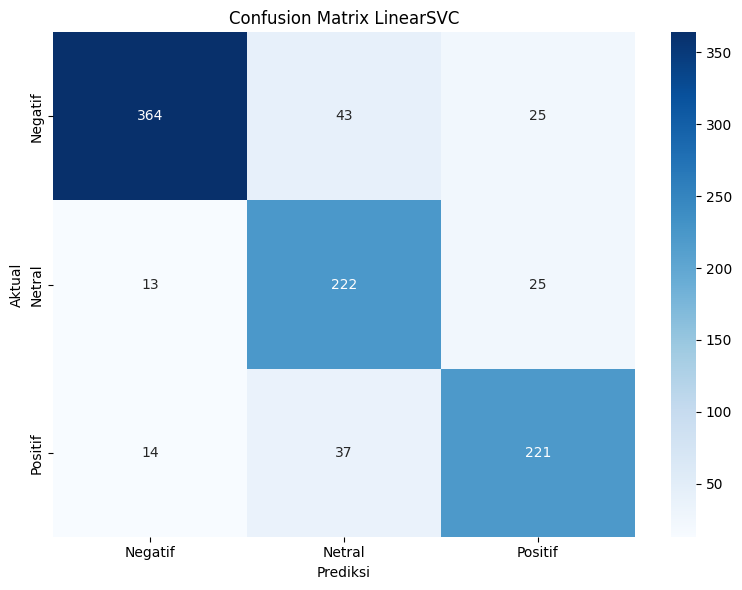

In [73]:
# ============================================================
# VISUALISASI CONFUSION MATRIX LINEARSVC
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Netral", "Positif"],
    yticklabels=["Negatif", "Netral", "Positif"]
)

plt.title("Confusion Matrix LinearSVC")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()

plt.savefig(
    f"{folder_path}/visualisasi_confusion_matrix_linearsvc_ros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
# ============================================================
# EVALUASI NAIVE BAYES DENGAN RANDOM OVERSAMPLING
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["negatif", "netral", "positif"]
)

print("CONFUSION MATRIX NAIVE BAYES")
print("Urutan label: negatif, netral, positif")
print(cm_nb)

print("\nCLASSIFICATION REPORT NAIVE BAYES")
print(
    classification_report(
        y_test,
        y_pred_nb,
        labels=["negatif", "netral", "positif"]
    )
)

CONFUSION MATRIX NAIVE BAYES
Urutan label: negatif, netral, positif
[[344  29  59]
 [ 46 153  61]
 [ 31  15 226]]

CLASSIFICATION REPORT NAIVE BAYES
              precision    recall  f1-score   support

     negatif       0.82      0.80      0.81       432
      netral       0.78      0.59      0.67       260
     positif       0.65      0.83      0.73       272

    accuracy                           0.75       964
   macro avg       0.75      0.74      0.74       964
weighted avg       0.76      0.75      0.75       964



In [75]:
# ============================================================
# PERBANDINGAN HASIL EVALUASI LINEARSVC DAN NAIVE BAYES
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Metrik LinearSVC
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(
    y_test, y_pred_svm,
    average="weighted"
)
recall_svm = recall_score(
    y_test, y_pred_svm,
    average="weighted"
)
f1_svm = f1_score(
    y_test, y_pred_svm,
    average="weighted"
)

# Metrik Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test, y_pred_nb,
    average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_nb,
    average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_nb,
    average="weighted"
)

# Membuat tabel perbandingan
tabel_perbandingan = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "LinearSVC": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm
    ],
    "Multinomial Naive Bayes": [
        accuracy_nb,
        precision_nb,
        recall_nb,
        f1_nb
    ]
})

# Mengubah nilai menjadi persentase
tabel_perbandingan["LinearSVC"] = (
    tabel_perbandingan["LinearSVC"] * 100
).round(2)

tabel_perbandingan["Multinomial Naive Bayes"] = (
    tabel_perbandingan["Multinomial Naive Bayes"] * 100
).round(2)

tabel_perbandingan

,Metrik,LinearSVC,Multinomial Naive Bayes
0,Accuracy,83.71,75.00
1,Precision,84.55,75.99
2,Recall,83.71,75.00
3,F1-score,83.92,74.84


In [76]:
# ============================================================
# MENYIMPAN TABEL PERBANDINGAN MODEL
# ============================================================

tabel_perbandingan.to_csv(
    f"{folder_path}/tabel_perbandingan_linearsvc_naive_bayes_ros.csv",
    index=False
)

print("Tabel perbandingan model berhasil disimpan ke Google Drive.")

Tabel perbandingan model berhasil disimpan ke Google Drive.


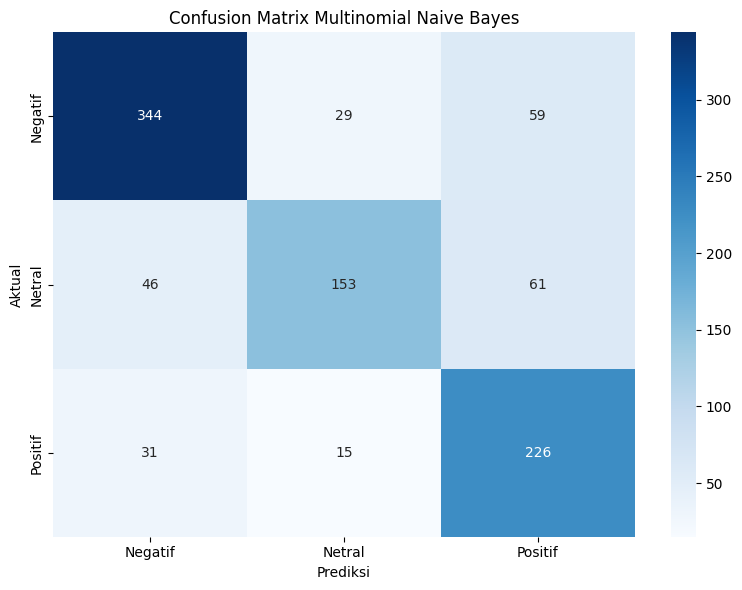

In [78]:
# ============================================================
# VISUALISASI CONFUSION MATRIX NAIVE BAYES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Netral", "Positif"],
    yticklabels=["Negatif", "Netral", "Positif"]
)

plt.title("Confusion Matrix Multinomial Naive Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()

plt.savefig(
    f"{folder_path}/visualisasi_confusion_matrix_naive_bayes_ros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
# ============================================================
# TABEL CONFUSION MATRIX NAIVE BAYES
# ============================================================

tabel_cm_nb = pd.DataFrame(
    cm_nb,
    index=["Aktual Negatif", "Aktual Netral", "Aktual Positif"],
    columns=["Prediksi Negatif", "Prediksi Netral", "Prediksi Positif"]
)

tabel_cm_nb

,Prediksi Negatif,Prediksi Netral,Prediksi Positif
Aktual Negatif,344,29,59
Aktual Netral,46,153,61
Aktual Positif,31,15,226


In [80]:
# ============================================================
# MENYIMPAN TABEL CONFUSION MATRIX NAIVE BAYES
# ============================================================

tabel_cm_nb.to_csv(
    f"{folder_path}/confusion_matrix_naive_bayes_ros.csv",
    index=True
)

print("Tabel confusion matrix Naive Bayes berhasil disimpan.")

Tabel confusion matrix Naive Bayes berhasil disimpan.


In [82]:
# ============================================================
# TABEL METRIK EVALUASI NAIVE BAYES DALAM PERSENTASE
# ============================================================

from sklearn.metrics import classification_report

laporan_nb = classification_report(
    y_test,
    y_pred_nb,
    labels=["negatif", "netral", "positif"],
    output_dict=True
)

tabel_metrik_nb = pd.DataFrame(laporan_nb).transpose()

tabel_metrik_nb = tabel_metrik_nb.loc[
    ["negatif", "netral", "positif", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

# Mengubah metrik menjadi persentase
kolom_persen = ["precision", "recall", "f1-score"]

tabel_metrik_nb[kolom_persen] = (
    tabel_metrik_nb[kolom_persen] * 100
).round(2)

# Membulatkan support menjadi bilangan bulat
tabel_metrik_nb["support"] = (
    tabel_metrik_nb["support"].astype(int)
)

tabel_metrik_nb

,precision,recall,f1-score,support
negatif,81.71,79.63,80.66,432
netral,77.66,58.85,66.96,260
positif,65.32,83.09,73.14,272
macro avg,74.90,73.85,73.58,964
weighted avg,75.99,75.00,74.84,964


In [83]:
# ============================================================
# MENYIMPAN TABEL METRIK NAIVE BAYES
# ============================================================

tabel_metrik_nb.to_csv(
    f"{folder_path}/tabel_metrik_naive_bayes_ros.csv",
    index=True
)

print("Tabel metrik Naive Bayes berhasil disimpan.")

Tabel metrik Naive Bayes berhasil disimpan.


In [84]:
# ============================================================
# TABEL METRIK EVALUASI LINEARSVC DALAM PERSENTASE
# ============================================================

from sklearn.metrics import classification_report

laporan_svm = classification_report(
    y_test,
    y_pred_svm,
    labels=["negatif", "netral", "positif"],
    output_dict=True
)

tabel_metrik_svm = pd.DataFrame(laporan_svm).transpose()

tabel_metrik_svm = tabel_metrik_svm.loc[
    ["negatif", "netral", "positif", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
]

# Mengubah metrik menjadi persentase
kolom_persen = ["precision", "recall", "f1-score"]

tabel_metrik_svm[kolom_persen] = (
    tabel_metrik_svm[kolom_persen] * 100
).round(2)

# Membulatkan support
tabel_metrik_svm["support"] = (
    tabel_metrik_svm["support"].astype(int)
)

tabel_metrik_svm

,precision,recall,f1-score,support
negatif,93.09,84.26,88.46,432
netral,73.51,85.38,79.00,260
positif,81.55,81.25,81.40,272
macro avg,82.72,83.63,82.95,964
weighted avg,84.55,83.71,83.92,964


In [85]:
# ============================================================
# MENYIMPAN TABEL METRIK LINEARSVC
# ============================================================

tabel_metrik_svm.to_csv(
    f"{folder_path}/tabel_metrik_linearsvc_ros.csv",
    index=True
)

print("Tabel metrik LinearSVC berhasil disimpan.")

Tabel metrik LinearSVC berhasil disimpan.


# 8.Perbandingan Performa Model

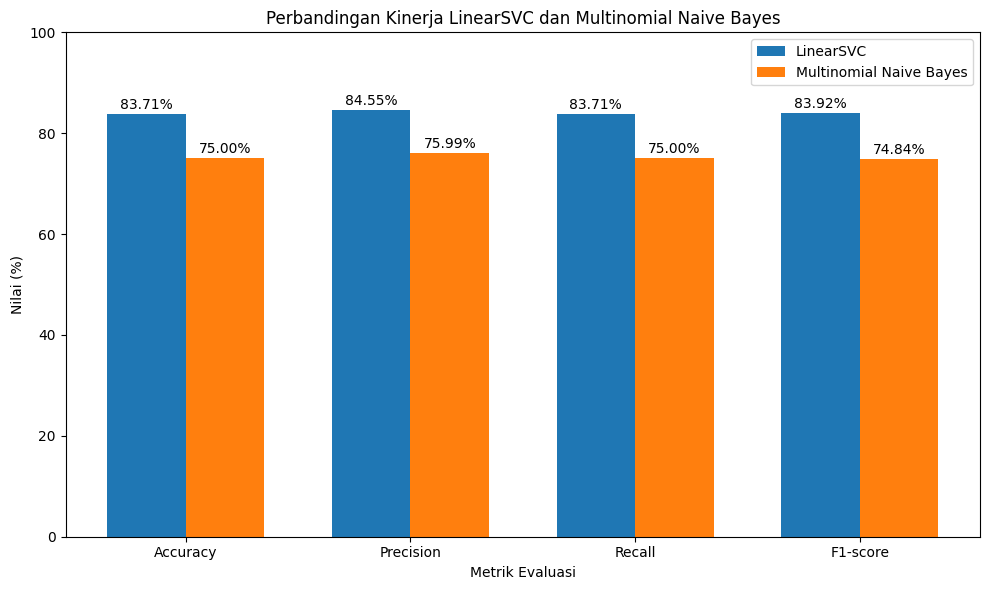

In [86]:
# ============================================================
# VISUALISASI PERBANDINGAN METRIK MODEL
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrik = tabel_perbandingan["Metrik"]
linearsvc = tabel_perbandingan["LinearSVC"]
naive_bayes = tabel_perbandingan["Multinomial Naive Bayes"]

x = np.arange(len(metrik))
lebar = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - lebar / 2,
    linearsvc,
    lebar,
    label="LinearSVC"
)

plt.bar(
    x + lebar / 2,
    naive_bayes,
    lebar,
    label="Multinomial Naive Bayes"
)

plt.xticks(x, metrik)
plt.xlabel("Metrik Evaluasi")
plt.ylabel("Nilai (%)")
plt.title("Perbandingan Kinerja LinearSVC dan Multinomial Naive Bayes")
plt.ylim(0, 100)
plt.legend()

# Menampilkan nilai di atas setiap batang
for i, nilai in enumerate(linearsvc):
    plt.text(
        i - lebar / 2,
        nilai + 1,
        f"{nilai:.2f}%",
        ha="center"
    )

for i, nilai in enumerate(naive_bayes):
    plt.text(
        i + lebar / 2,
        nilai + 1,
        f"{nilai:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{folder_path}/visualisasi_perbandingan_model_ros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
# ============================================================
# SELISIH HASIL EVALUASI LINEARSVC DAN NAIVE BAYES
# ============================================================

tabel_selisih = tabel_perbandingan.copy()

tabel_selisih["Selisih"] = (
    tabel_selisih["LinearSVC"] -
    tabel_selisih["Multinomial Naive Bayes"]
).round(2)

tabel_selisih

,Metrik,LinearSVC,Multinomial Naive Bayes,Selisih
0,Accuracy,83.71,75.00,8.71
1,Precision,84.55,75.99,8.56
2,Recall,83.71,75.00,8.71
3,F1-score,83.92,74.84,9.08


In [88]:
# ============================================================
# MENYIMPAN TABEL SELISIH METRIK
# ============================================================

tabel_selisih.to_csv(
    f"{folder_path}/tabel_selisih_metrik_model_ros.csv",
    index=False
)

print("Tabel selisih metrik berhasil disimpan.")

Tabel selisih metrik berhasil disimpan.


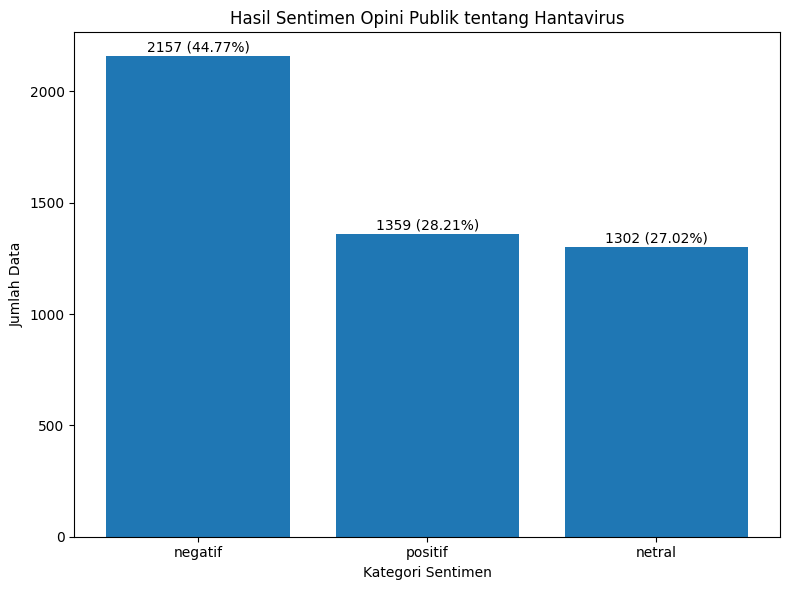

In [93]:
# ============================================================
# VISUALISASI DISTRIBUSI SENTIMEN DENGAN PERSENTASE
# ============================================================

import matplotlib.pyplot as plt

distribusi_sentimen = df["label"].value_counts()

total_data = distribusi_sentimen.sum()
persentase_sentimen = (distribusi_sentimen / total_data) * 100

plt.figure(figsize=(8, 6))

bars = plt.bar(
    distribusi_sentimen.index,
    distribusi_sentimen.values
)

plt.title("Hasil Sentimen Opini Publik tentang Hantavirus")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)

# Menampilkan jumlah dan persentase
for bar, jumlah, persen in zip(
    bars,
    distribusi_sentimen.values,
    persentase_sentimen.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{jumlah} ({persen:.2f}%)",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{folder_path}/visualisasi_distribusi_sentimen_persentase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()